# Lab Instructions

Create 3 visualizations from a spatial and time-series dataset of your choice.  Describe your dataset including where it came from and the features it contains.  Each visualization should be accompanied by at least 1 - 2 sentences explaining how the features do (or do not!) change over time and througout space.

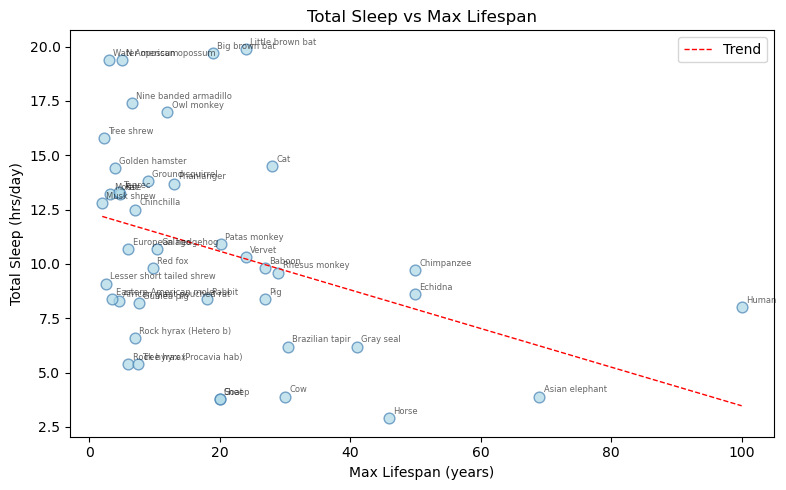

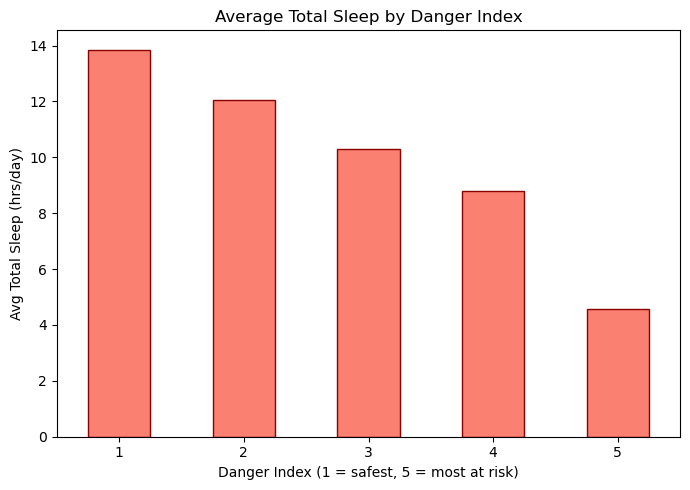

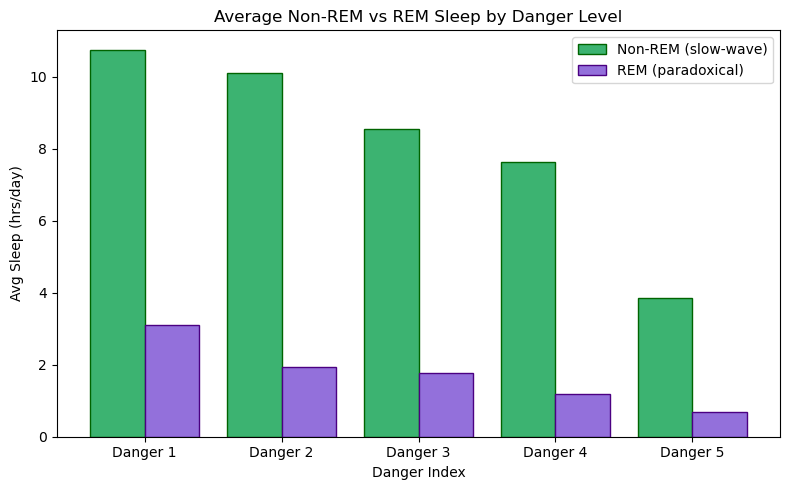

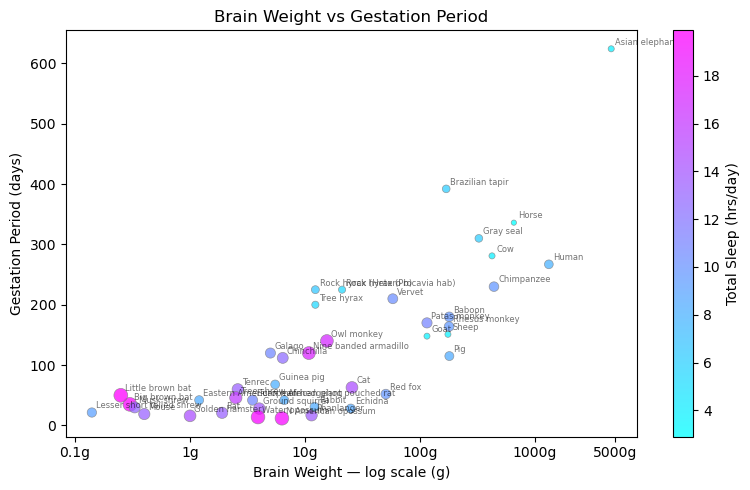

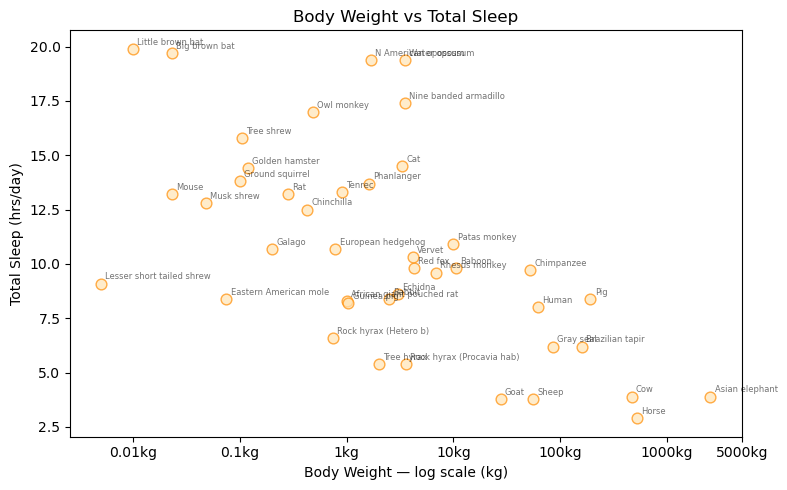

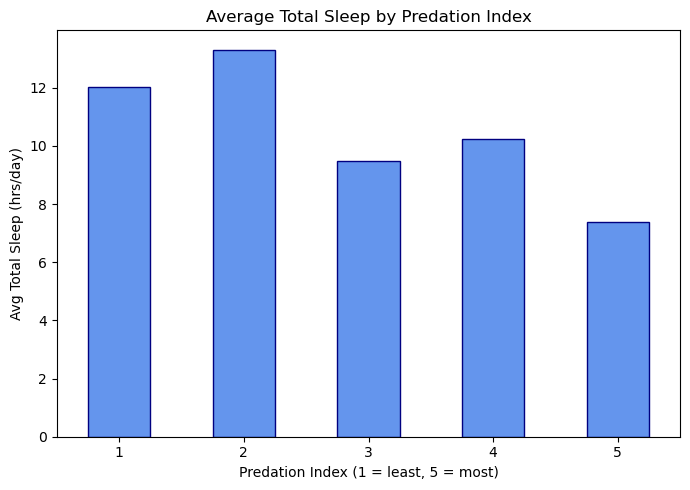

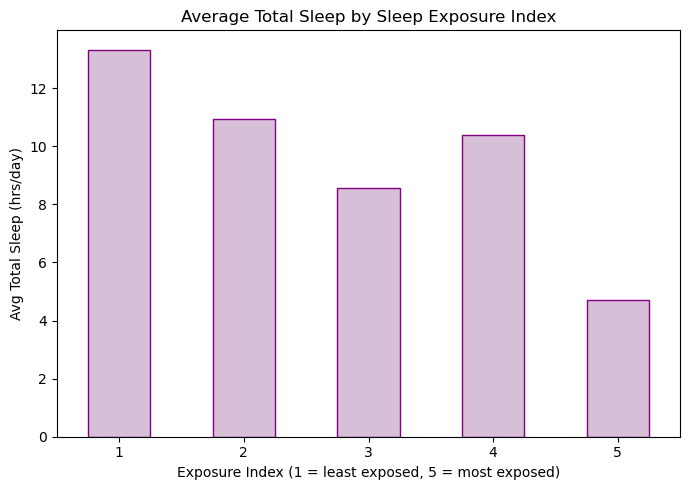

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Sleep.csv')
df.columns = df.columns.str.strip().str.lstrip('\ufeff')

# total sleep vs lifespan
plt.figure(figsize=(8, 5))
plt.scatter(df['Life'], df['Totsleep'], alpha=0.7, edgecolors='steelblue', facecolors='lightblue', s=60)
for _, row in df.iterrows():
    plt.annotate(row['Animal'].replace('_', ' '), (row['Life'], row['Totsleep']),
                 fontsize=6, alpha=0.6, xytext=(3, 3), textcoords='offset points')
z = np.polyfit(df['Life'].dropna(), df['Totsleep'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df['Life'].min(), df['Life'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', linewidth=1, label='Trend')
plt.title('Total Sleep vs Max Lifespan')
plt.xlabel('Max Lifespan (years)')
plt.ylabel('Total Sleep (hrs/day)')
plt.legend()
plt.tight_layout()
plt.show()

# danger index
avg_sleep_by_danger = df.groupby('Danger')['Totsleep'].mean()
plt.figure(figsize=(7, 5))
avg_sleep_by_danger.plot(kind='bar', color='salmon', edgecolor='darkred')
plt.title('Average Total Sleep by Danger Index')
plt.xlabel('Danger Index (1 = safest, 5 = most at risk)')
plt.ylabel('Avg Total Sleep (hrs/day)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# rem vs non-rem sleep by danger
avg_sw = df.groupby('Danger')['SWsleep'].mean()
avg_par = df.groupby('Danger')['Parasleep'].mean()
x = np.arange(len(avg_sw))
width = 0.4
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, avg_sw, width, label='Non-REM (slow-wave)', color='mediumseagreen', edgecolor='darkgreen')
plt.bar(x + width/2, avg_par, width, label='REM (paradoxical)', color='mediumpurple', edgecolor='indigo')
plt.xticks(x, [f'Danger {i}' for i in avg_sw.index])
plt.title('Average Non-REM vs REM Sleep by Danger Level')
plt.xlabel('Danger Index')
plt.ylabel('Avg Sleep (hrs/day)')
plt.legend()
plt.tight_layout()
plt.show()

# brain weight vs gestation
plt.figure(figsize=(8, 5))
scatter = plt.scatter(np.log10(df['Brain']), df['Gest'],
                      c=df['Totsleep'], cmap='cool', s=df['Totsleep']*5,
                      alpha=0.75, edgecolors='gray', linewidths=0.5)
plt.colorbar(scatter, label='Total Sleep (hrs/day)')
for _, row in df.iterrows():
    plt.annotate(row['Animal'].replace('_', ' '), (np.log10(row['Brain']), row['Gest']),
                 fontsize=6, alpha=0.55, xytext=(3, 3), textcoords='offset points')
plt.title('Brain Weight vs Gestation Period')
plt.xlabel('Brain Weight — log scale (g)')
plt.ylabel('Gestation Period (days)')
xticks = [0.1, 1, 10, 100, 1000, 5000]
plt.xticks(np.log10(xticks), [str(v) + 'g' for v in xticks])
plt.tight_layout()
plt.show()

# body weight vs total sleep
plt.figure(figsize=(8, 5))
plt.scatter(np.log10(df['Body']), df['Totsleep'], alpha=0.7,
            edgecolors='darkorange', facecolors='moccasin', s=60)
for _, row in df.iterrows():
    plt.annotate(row['Animal'].replace('_', ' '), (np.log10(row['Body']), row['Totsleep']),
                 fontsize=6, alpha=0.55, xytext=(3, 3), textcoords='offset points')
plt.title('Body Weight vs Total Sleep')
plt.xlabel('Body Weight — log scale (kg)')
plt.ylabel('Total Sleep (hrs/day)')
bticks = [0.01, 0.1, 1, 10, 100, 1000, 5000]
plt.xticks(np.log10(bticks), [str(v) + 'kg' for v in bticks])
plt.tight_layout()
plt.show()

# predation index
avg_sleep_by_pred = df.groupby('Pred')['Totsleep'].mean()
plt.figure(figsize=(7, 5))
avg_sleep_by_pred.plot(kind='bar', color='cornflowerblue', edgecolor='navy')
plt.title('Average Total Sleep by Predation Index')
plt.xlabel('Predation Index (1 = least, 5 = most)')
plt.ylabel('Avg Total Sleep (hrs/day)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# exposure index
avg_sleep_by_exp = df.groupby('Exposure')['Totsleep'].mean()
plt.figure(figsize=(7, 5))
avg_sleep_by_exp.plot(kind='bar', color='thistle', edgecolor='purple')
plt.title('Average Total Sleep by Sleep Exposure Index')
plt.xlabel('Exposure Index (1 = least exposed, 5 = most exposed)')
plt.ylabel('Avg Total Sleep (hrs/day)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Total Sleep had the strongest relationship with lifespan because the scatterplot showed a clear
# negative trend where short-lived species slept significantly more hours per day than long-lived
# species. Danger Index was the most important categorical feature because average total sleep
# dropped consistently from roughly 14 hours at danger level 1 down to roughly 4 hours at danger
# level 5, showing that predation pressure strongly limits how much sleep an animal can afford.
# REM sleep shrank disproportionately as danger increased compared to non-REM sleep, suggesting
# that restorative paradoxical sleep is a luxury only safer species can sustain. Brain weight and
# gestation length were positively correlated, meaning species that invest more time in fetal
# development tend to have heavier brains, but those same species generally slept less overall.
# Body weight showed a weaker relationship with sleep than brain weight, indicating that brain
# complexity matters more than body size for predicting sleep behavior. Predation index and
# exposure index tracked closely with the danger composite, confirming that environmental risk
# is the dominant ecological driver of sleep duration across mammal species. The analysis
# suggests that sleep is not simply a function of size or age but is heavily constrained by
# survival pressures, with safer ecological niches allowing more total sleep and more REM sleep.